# Analysis

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [114]:
udf_raw = pd.read_csv("results_uni.csv", sep=';', header=None, names=["algo", "threads", "t", "t1", "t2", "t3", "t4", "t5"])
udf_raw.head()

,algo,threads,t,t1,t2,t3,t4,t5
0,sort_1,13,0.384853,0.019386,0.088714,0.140986,0.002560,NaN
1,sort_1,13,0.399340,0.025448,0.088701,0.141066,0.002224,NaN
2,sort_1,13,0.388864,0.019547,0.088918,0.140238,0.002518,NaN
3,sort_1,13,0.385160,0.023398,0.088729,0.140316,0.002281,NaN
4,sort_1,13,0.400057,0.021623,0.088660,0.140553,0.002288,NaN


In [115]:
bdf_raw = pd.read_csv("results.csv", sep=';', header=None, names=["algo", "threads", "buckets", "t", "t1", "t2", "t3", "t4", "t5"])
bdf_raw.head()

,algo,threads,buckets,t,t1,t2,t3,t4,t5
0,sort_1,100000,2.273125,0.101698,0.635090,1.359729,0.020603,NaN,NaN
1,sort_1,35000,2.475707,0.102941,0.648740,1.625841,0.021095,NaN,NaN
2,sort_1,50000,2.482652,0.102780,0.709927,1.542029,0.022661,NaN,NaN
3,sort_1,20000,2.500448,0.102594,0.581902,1.751759,0.018015,NaN,NaN
4,sort_1,8000,2.585771,0.102740,0.477317,1.966189,0.015851,NaN,NaN


In [116]:
odf_raw = pd.read_csv("results_oriented.csv", sep=';', header=None, names=["algo", "threads", "buckets", "t", "t1", "t2", "t3", "t4", "t5"])
odf_raw.head()

,algo,threads,buckets,t,t1,t2,t3,t4,t5
0,sort_1,15,105000,0.459567,0.007174,0.111006,0.044003,0.006581,NaN
1,sort_1,15,105000,0.469376,0.007593,0.111909,0.044219,0.007158,NaN
2,sort_1,15,105000,0.464482,0.007434,0.112374,0.044091,0.007162,NaN
3,sort_1,15,105000,0.471726,0.007238,0.112708,0.044242,0.006757,NaN
4,sort_1,15,105000,0.462513,0.007536,0.111100,0.044249,0.007432,NaN


In [157]:
udf = udf_raw.groupby(['algo', 'threads']).agg(
    t_mean=('t', 'mean'), t_std=('t', 'std'),
    t1_mean=('t1', 'mean'), t1_std=('t1', 'std'),
    t2_mean=('t2', 'mean'), t2_std=('t2', 'std'),
    t3_mean=('t3', 'mean'), t3_std=('t3', 'std'),
    t4_mean=('t4', 'mean'), t4_std=('t4', 'std'),
    t5_mean=('t5', 'mean'), t5_std=('t5', 'std')
).reset_index()

udf.head()

,algo,threads,t_mean,t_std,t1_mean,t1_std,t2_mean,t2_std,t3_mean,t3_std,t4_mean,t4_std,t5_mean,t5_std
0,sort_1,1,2.933343,0.083828,0.101914,0.003466,0.327319,0.007618,2.479094,0.081983,0.015520,0.000545,NaN,NaN
1,sort_1,2,1.474123,0.002945,0.050622,0.000357,0.294817,0.001831,1.101163,0.001377,0.007577,0.000470,NaN,NaN
2,sort_1,3,1.202074,0.077313,0.039795,0.008755,0.259326,0.025896,0.809924,0.059128,0.005619,0.001114,NaN,NaN
3,sort_1,4,0.946481,0.058758,0.027840,0.004697,0.206496,0.022684,0.592133,0.046383,0.004379,0.000827,NaN,NaN
4,sort_1,5,0.727978,0.061909,0.025007,0.005902,0.168935,0.042085,0.409374,0.000634,0.003872,0.000538,NaN,NaN


In [156]:
bdf = bdf_raw.groupby(['algo', 'buckets']).agg(
    t_mean=('t', 'mean'), t_std=('t', 'std'),
    t1_mean=('t1', 'mean'), t1_std=('t1', 'std'),
    t2_mean=('t2', 'mean'), t2_std=('t2', 'std'),
    t3_mean=('t3', 'mean'), t3_std=('t3', 'std'),
    t4_mean=('t4', 'mean'), t4_std=('t4', 'std'),
    t5_mean=('t5', 'mean'), t5_std=('t5', 'std')
).reset_index()

bdf.head()

,algo,buckets,t_mean,t_std,t1_mean,t1_std,t2_mean,t2_std,t3_mean,t3_std,t4_mean,t4_std,t5_mean,t5_std
0,sort_1,2.273125,0.101698,NaN,0.635090,NaN,1.359729,NaN,0.020603,NaN,NaN,NaN,NaN,NaN
1,sort_1,2.475707,0.102941,NaN,0.648740,NaN,1.625841,NaN,0.021095,NaN,NaN,NaN,NaN,NaN
2,sort_1,2.482652,0.102780,NaN,0.709927,NaN,1.542029,NaN,0.022661,NaN,NaN,NaN,NaN,NaN
3,sort_1,2.500448,0.102594,NaN,0.581902,NaN,1.751759,NaN,0.018015,NaN,NaN,NaN,NaN,NaN
4,sort_1,2.585771,0.102740,NaN,0.477317,NaN,1.966189,NaN,0.015851,NaN,NaN,NaN,NaN,NaN


In [159]:
odf = odf_raw.groupby(['algo', 'threads', 'buckets']).agg(
    t_mean=('t', 'mean'), t_std=('t', 'std'),
    t1_mean=('t1', 'mean'), t1_std=('t1', 'std'),
    t2_mean=('t2', 'mean'), t2_std=('t2', 'std'),
    t3_mean=('t3', 'mean'), t3_std=('t3', 'std'),
    t4_mean=('t4', 'mean'), t4_std=('t4', 'std'),
    t5_mean=('t5', 'mean'), t5_std=('t5', 'std')
).reset_index()

odf.head()

,algo,threads,buckets,t_mean,t_std,t1_mean,t1_std,t2_mean,t2_std,t3_mean,t3_std,t4_mean,t4_std,t5_mean,t5_std
0,sort_1,1,7000,2.569332,0.005161,0.101170,0.000281,0.448485,0.004379,1.984214,0.003012,0.015850,0.000635,NaN,NaN
1,sort_1,2,14000,1.348704,0.057319,0.055956,0.012287,0.362647,0.023178,0.857323,0.045029,0.012004,0.007394,NaN,NaN
2,sort_1,3,21000,0.999234,0.052958,0.039194,0.013469,0.279895,0.028194,0.520010,0.028656,0.008447,0.002706,NaN,NaN
3,sort_1,4,28000,0.792791,0.032958,0.025647,0.000152,0.203587,0.002022,0.328393,0.001212,0.007275,0.000381,NaN,NaN
4,sort_1,5,35000,0.663867,0.028392,0.020623,0.000164,0.180046,0.001616,0.243724,0.000842,0.006213,0.000638,NaN,NaN


# Execution time

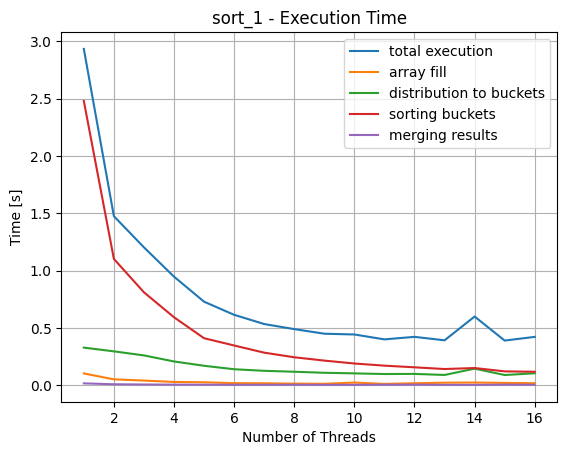

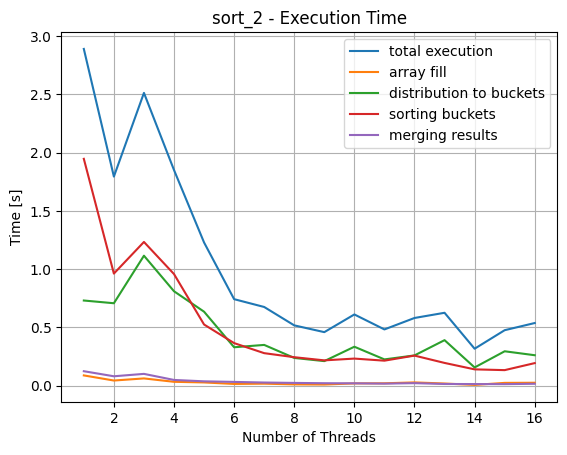

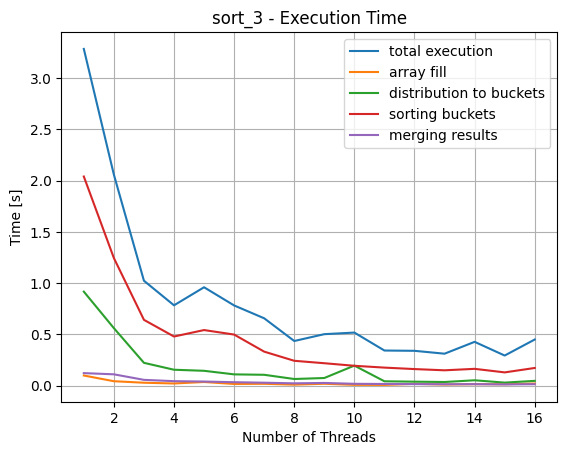

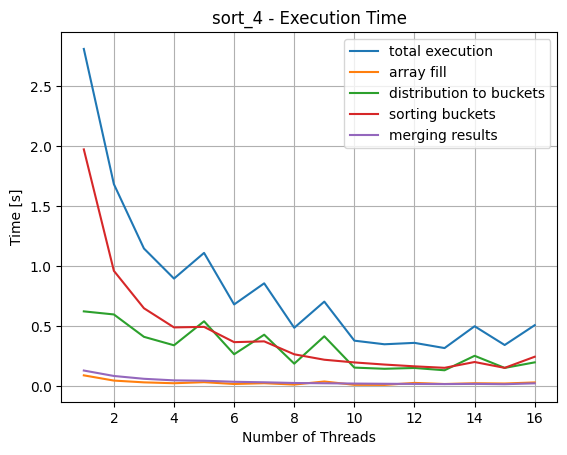

In [160]:
for series in udf.groupby(["algo"]):
    series_df = series[1]
    series_nm = series[0][0]
    
    plt.plot(series_df["threads"], series_df["t_mean"], label="total execution")
    plt.plot(series_df["threads"], series_df["t1_mean"], label="array fill")
    plt.plot(series_df["threads"], series_df["t2_mean"], label="distribution to buckets")
    plt.plot(series_df["threads"], series_df["t3_mean"], label="sorting buckets")
    plt.plot(series_df["threads"], series_df["t4_mean"], label="merging results")
    
    plt.title(f"{series_nm} - Execution Time")
    plt.legend()
    plt.xlabel("Number of Threads")
    plt.ylabel("Time [s]")
    plt.grid()
    plt.show()

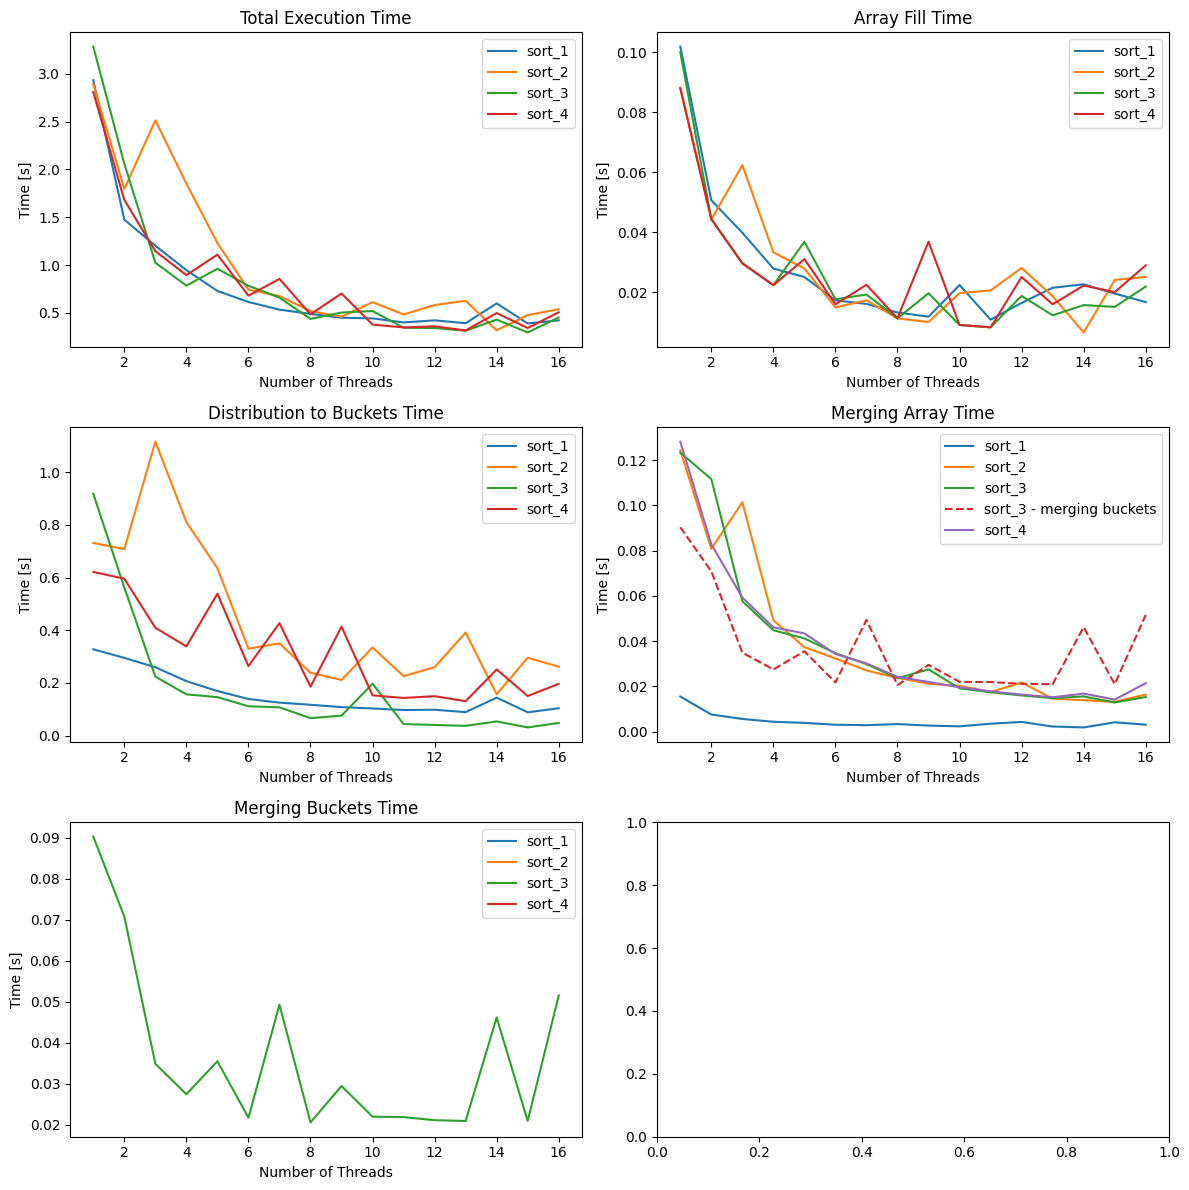

In [187]:
total_ex_times = []
array_fill_times = []
distribution_times = []
sorting_times = []
merging_times = []
merging_buckets_times_sort_3 = []

for series in udf.groupby(["algo"]):
    series_df = series[1]
    series_nm = series[0][0]

    total_ex_times.append(series_df["t_mean"].values)
    array_fill_times.append(series_df["t1_mean"].values)
    distribution_times.append(series_df["t2_mean"].values)
    sorting_times.append(series_df["t3_mean"].values)
    merging_times.append(series_df["t4_mean"].values)
    # Non NaN for sort_3
    merging_buckets_times_sort_3.append(series_df["t5_mean"].values)

fig, ax = plt.subplots(3,2, figsize=(12,12))

# Total Execution Time
i, j = 0, 0
for sort_no, data in enumerate(total_ex_times):
    ax[i][j].plot(series_df["threads"], data, label=f"sort_{sort_no+1}")
ax[i][j].set_title("Total Execution Time")
ax[i][j].set_xlabel("Number of Threads")
ax[i][j].set_ylabel("Time [s]")
ax[i][j].legend()

# Array Fill Time
i, j = 0, 1
for sort_no, data in enumerate(array_fill_times):
    ax[i][j].plot(series_df["threads"], data, label=f"sort_{sort_no+1}")
ax[i][j].set_title("Array Fill Time")
ax[i][j].set_xlabel("Number of Threads")
ax[i][j].set_ylabel("Time [s]")
ax[i][j].legend()

# Distribution to Buckets Time
i, j = 1, 0
for sort_no, data in enumerate(distribution_times):
    ax[i][j].plot(series_df["threads"], data, label=f"sort_{sort_no+1}")
ax[i][j].set_title("Distribution to Buckets Time")
ax[i][j].set_xlabel("Number of Threads")
ax[i][j].set_ylabel("Time [s]")
ax[i][j].legend()

# Merging array Time
i, j = 1, 1
for sort_no, data in enumerate(merging_times):
    ax[i][j].plot(series_df["threads"], data, label=f"sort_{sort_no+1}")
    if not np.isnan(merging_buckets_times_sort_3[sort_no]).all():
        ax[i][j].plot(series_df["threads"], merging_buckets_times_sort_3[sort_no], label=f"sort_{sort_no+1} - merging buckets", linestyle='dashed')
ax[i][j].set_title("Merging Array Time")
ax[i][j].set_xlabel("Number of Threads")
ax[i][j].set_ylabel("Time [s]")
ax[i][j].legend()

# Merging Buckets Time (sort_3)
i, j = 2, 0
for sort_no, data in enumerate(merging_buckets_times_sort_3):
    ax[i][j].plot(series_df["threads"], data, label=f"sort_{sort_no+1}")
ax[i][j].set_title("Merging Buckets Time")
ax[i][j].set_xlabel("Number of Threads")
ax[i][j].set_ylabel("Time [s]")
ax[i][j].legend()

plt.tight_layout()

In [184]:
np.isnan(merging_buckets_times_sort_3[2]).all()

np.False_

In [123]:
total_ex_times

[array([2.93334264, 1.47412251, 1.20207371, 0.94648138, 0.72797775,
        0.61359472, 0.53308384, 0.48878218, 0.44866749, 0.44188169,
        0.39930431, 0.42125098, 0.39113408, 0.59842928, 0.38888165,
        0.42107162]),
 array([2.89130118, 1.79525713, 2.51372293, 1.85153743, 1.22938126,
        0.742733  , 0.67569333, 0.5177879 , 0.45972273, 0.61150691,
        0.48298908, 0.5812764 , 0.62587651, 0.31733551, 0.47635239,
        0.53790423]),
 array([3.28485409, 2.0586181 , 1.02419562, 0.78455636, 0.96058032,
        0.78324887, 0.65795102, 0.43644687, 0.50316397, 0.51865224,
        0.34361162, 0.34081952, 0.31274652, 0.42832076, 0.29475934,
        0.45099809]),
 array([2.80821562, 1.68141913, 1.14505033, 0.89446401, 1.10843381,
        0.67876636, 0.85483355, 0.48439045, 0.70247143, 0.37699703,
        0.3469793 , 0.35865781, 0.31532014, 0.49719977, 0.34076731,
        0.50610116])]

In [ ]:
# plt.plot(series_df["threads"], series_df["t_mean"], label="total execution")
# plt.plot(series_df["threads"], series_df["t1_mean"], label="array fill")
# plt.plot(series_df["threads"], series_df["t2_mean"], label="distribution to buckets")
# plt.plot(series_df["threads"], series_df["t3_mean"], label="sorting buckets")
# plt.plot(series_df["threads"], series_df["t4_mean"], label="merging results")

plt.title(f"{series_nm} - Execution Time")
plt.legend()
plt.xlabel("Number of Threads")
plt.ylabel("Time [s]")
plt.grid()
plt.show()

# Speedup

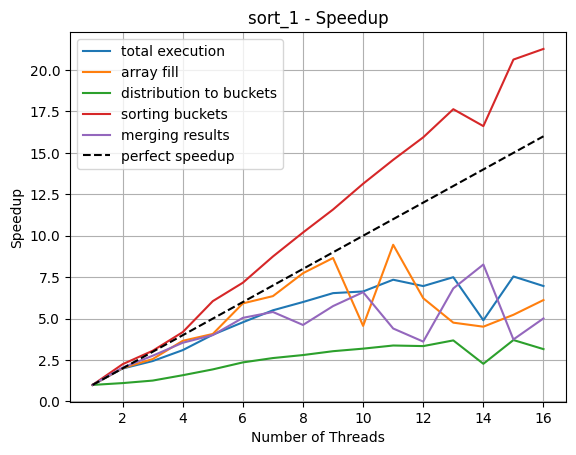

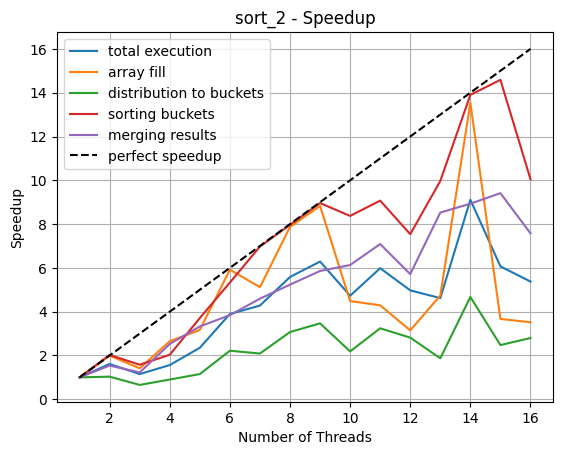

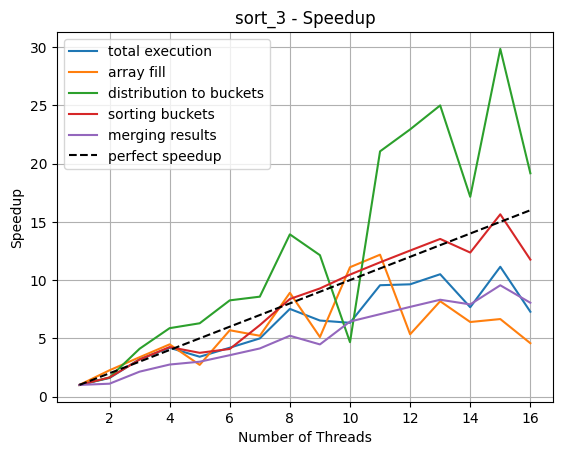

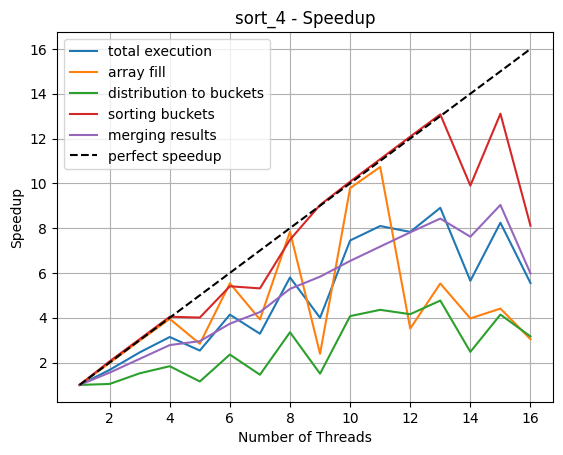

In [30]:
for series in udf.groupby(["algo"]):
    series_df = series[1]
    series_nm = series[0][0]
    
    T1 = series_df[series_df["threads"] == 1]["t_mean"].values[0]
    T11 = series_df[series_df["threads"] == 1]["t1_mean"].values[0]
    T12 = series_df[series_df["threads"] == 1]["t2_mean"].values[0]
    T13 = series_df[series_df["threads"] == 1]["t3_mean"].values[0]
    T14 = series_df[series_df["threads"] == 1]["t4_mean"].values[0]
    
    plt.plot(series_df["threads"], T1/series_df["t_mean"], label="total execution")
    plt.plot(series_df["threads"], T11/series_df["t1_mean"], label="array fill")
    plt.plot(series_df["threads"], T12/series_df["t2_mean"], label="distribution to buckets")
    plt.plot(series_df["threads"], T13/series_df["t3_mean"], label="sorting buckets")
    plt.plot(series_df["threads"], T14/series_df["t4_mean"], label="merging results")
    
    perfect_speedup = series_df["threads"].values
    plt.plot(perfect_speedup, perfect_speedup, label="perfect speedup", linestyle='--', color='black')
    
    plt.title(f"{series_nm} - Speedup")
    plt.legend()
    plt.xlabel("Number of Threads")
    plt.grid()
    plt.ylabel("Speedup")
    plt.show()

# Buckets analysis

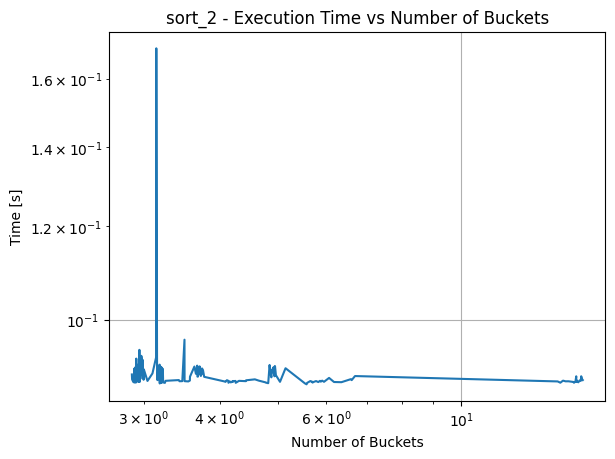

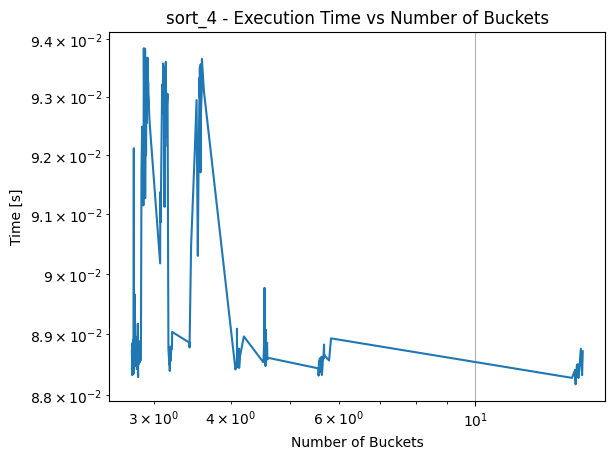

In [111]:
for series in bdf.groupby(["algo"]):
    series_df = series[1]
    series_nm = series[0][0]

    if series[0][0] == "sort_1":
        continue
 
    plt.plot(series_df["buckets"], series_df["t_mean"], label="total execution")
    # plt.plot(series_df["buckets"], series_df["t1_mean"], label="array fill")
    # plt.plot(series_df["buckets"], series_df["t2_mean"], label="distribution to buckets")
    # plt.plot(series_df["buckets"], series_df["t3_mean"], label="sorting buckets")
    # plt.plot(series_df["buckets"], series_df["t4_mean"], label="merging results")
    
    plt.title(f"{series_nm} - Execution Time vs Number of Buckets")
    # plt.legend()
    plt.xlabel("Number of Buckets")
    plt.ylabel("Time [s]")
    plt.yscale("log")
    plt.xscale("log")
    plt.grid()

    min_index = series_df["t_mean"].idxmin()
    min_value = series_df["t_mean"].min()
    # min_buckets = series_df["buckets"].iloc[min_index]
    # plt.annotate(f"min: {min_value:.2f}s buckets: {min_buckets}", xy=(min_buckets, min_value), xytext=(min_buckets*0.05, min_value*1.5),
    #              arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.show()

In [89]:
series_df["buckes"]

KeyError: 'buckes'

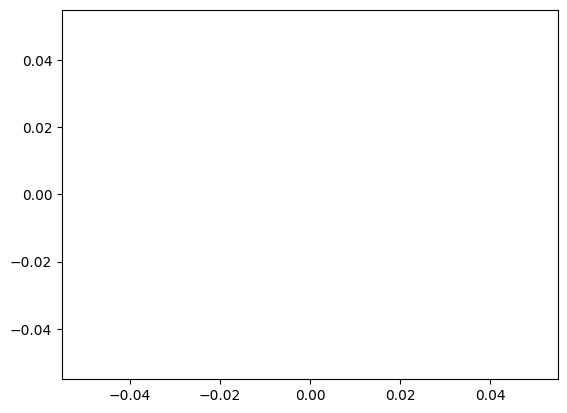

In [102]:
# Calculate the mean execution time for both algorithms
plt.plot(bdf[bdf["algo"] == "sort_1"]["buckets"], bdf[bdf["algo"] == "sort_1"]["t_mean"], label="sort_1", marker="o")

# plt.plot(series_df["buckets"], series_df["t_mean"], label="total execution")
# # plt.plot(series_df["buckets"], series_df["t1_mean"], label="array fill")
# # plt.plot(series_df["buckets"], series_df["t2_mean"], label="distribution to buckets")
# # plt.plot(series_df["buckets"], series_df["t3_mean"], label="sorting buckets")
# # plt.plot(series_df["buckets"], series_df["t4_mean"], label="merging results")

# plt.title(f"{series_nm} - Execution Time vs Number of Buckets")
# # plt.legend()
# plt.xlabel("Number of Buckets")
# plt.ylabel("Time [s]")
# plt.yscale("log")
# # plt.xscale("log")
# plt.grid()

# min_index = series_df["t_mean"].idxmin()
# min_value = series_df["t_mean"].min()
# # min_buckets = series_df["buckets"].iloc[min_index-20]
# # plt.annotate(f"min: {min_value:.2f}s buckets: {min_buckets}", xy=(min_buckets, min_value), xytext=(min_buckets*0.05, min_value*1.5),
# #              arrowprops=dict(facecolor='black', arrowstyle='->'))

# plt.show()

# Sort 2/4 oriented analysis

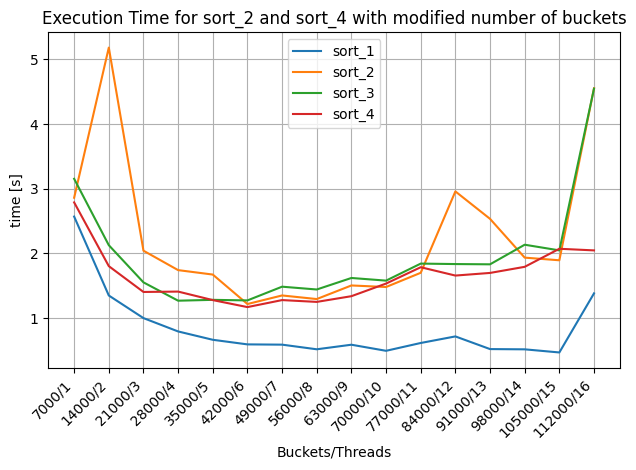

In [55]:
for series in odf.groupby("algo"):
    series_df = series[1]
    series_nm = series[0]
    
    # Create a combined x-axis label
    x_labels = [f"{buckets}/{threads}" for buckets, threads in zip(series_df["buckets"], series_df["threads"])]
    
    plt.plot(x_labels, series_df["t_mean"], label=f"{series_nm}")

plt.title("Execution Time for sort_2 and sort_4 with modified number of buckets")
plt.xlabel("Buckets/Threads")
plt.ylabel("time [s]")
plt.xticks(rotation=45, ha="right")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

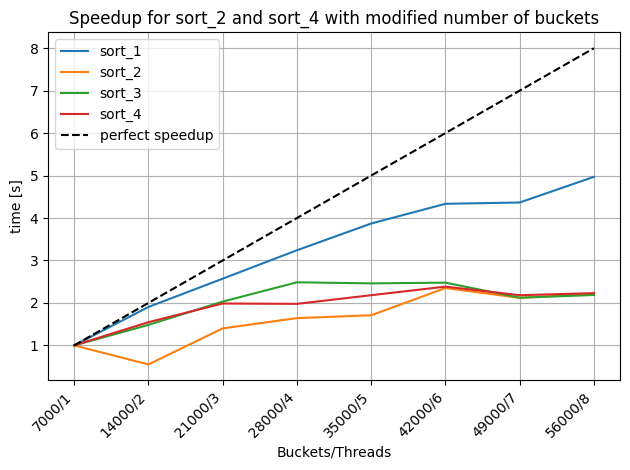

In [52]:
for series in odf.groupby("algo"):
    series_df = series[1][series[1]["threads"] <= 8]
    series_nm = series[0]
    
    # Create a combined x-axis label
    x_labels = [f"{buckets}/{threads}" for buckets, threads in zip(series_df["buckets"], series_df["threads"])]
    
    T1 = series_df[series_df["threads"] == 1]["t_mean"].values[0]
    
    plt.plot(x_labels, T1/series_df["t_mean"], label=f"{series_nm}")
    

X = np.arange(0, len(x_labels))
Y = np.arange(1, len(x_labels)+1)
plt.plot(X, Y, label="perfect speedup", linestyle='--', color='black')

plt.title("Speedup for sort_2 and sort_4 with modified number of buckets")
plt.xlabel("Buckets/Threads")
plt.ylabel("time [s]")
plt.xticks(rotation=45, ha="right")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()